In [9]:
import os
import csv
import torch
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data.sampler import SubsetRandomSampler

class GTSRBDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for c in range(0, 43):
            sub_folder = os.path.join(root_dir, format(c, '05d'))
            csv_file = os.path.join(sub_folder, 'GT-' + format(c, '05d') + '.csv')
            with open(csv_file, 'r') as f:
                reader = csv.reader(f, delimiter=';')
                next(reader)
                for row in reader:
                    img_filename = row[0]
                    img_path = os.path.join(sub_folder, img_filename)
                    self.image_paths.append(img_path)
                    self.labels.append(int(row[7]))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


def create_split_loaders(dataset, imgs_per_class, batch_size=1, seed=1):
    np.random.seed(seed)

    train_indices = []
    val_indices   = []
    test_indices  = []

    start_idx = 0

    for count in imgs_per_class:
        end_idx = start_idx + count

        train_end = start_idx + int(0.70 * count) # 70% for training
        val_end   = start_idx + int(0.90 * count) # 20% for validation, 10% for test

        train_slice = list(range(start_idx, train_end))
        val_slice   = list(range(train_end, val_end))
        test_slice  = list(range(val_end, end_idx))

        train_indices.extend(train_slice)
        val_indices.extend(val_slice)
        test_indices.extend(test_slice)

        start_idx = end_idx

    np.random.shuffle(train_indices)

    train_sampler = SubsetRandomSampler(train_indices)
    val_sampler   = SubsetRandomSampler(val_indices)
    test_sampler  = SubsetRandomSampler(test_indices)

    train_loader = DataLoader(dataset, batch_size=batch_size,
                              sampler=train_sampler, num_workers=1)
    val_loader   = DataLoader(dataset, batch_size=batch_size,
                              sampler=val_sampler,   num_workers=1)
    test_loader  = DataLoader(dataset, batch_size=batch_size,
                              sampler=test_sampler,  num_workers=1)

    return train_loader, val_loader, test_loader

def examine_folder_structure(root_dir):
    counts = []
    subfolders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
    subfolders.sort()
    for sub in subfolders:
        sub_path = os.path.join(root_dir, sub)
        count = sum(1 for f in os.listdir(sub_path) if f.lower().endswith(('.ppm', '.jpg', '.png')))
        print(f"{sub} contains {count} images.")
        counts.append(count)
    return counts

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.RandomRotation(15), # Add random rotation of 15 degrees to mimic real world circumstance
])

# Download Through: https://benchmark.ini.rub.de/
# File name: GTSRB-Training_fixed.zip
# URL: https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/published-archive.html
dir = '/content/drive/MyDrive/GTSRB/Training'

dataset = GTSRBDataset(dir, transform=transform)

imgs_per_class = examine_folder_structure(dir)

00000 contains 150 images.
00001 contains 1500 images.
00002 contains 1500 images.
00003 contains 960 images.
00004 contains 1320 images.
00005 contains 1260 images.
00006 contains 300 images.
00007 contains 960 images.
00008 contains 960 images.
00009 contains 990 images.
00010 contains 1350 images.
00011 contains 900 images.
00012 contains 1410 images.
00013 contains 1440 images.
00014 contains 540 images.
00015 contains 420 images.
00016 contains 300 images.
00017 contains 750 images.
00018 contains 810 images.
00019 contains 150 images.
00020 contains 240 images.
00021 contains 240 images.
00022 contains 270 images.
00023 contains 360 images.
00024 contains 180 images.
00025 contains 1020 images.
00026 contains 420 images.
00027 contains 180 images.
00028 contains 360 images.
00029 contains 180 images.
00030 contains 300 images.
00031 contains 540 images.
00032 contains 180 images.
00033 contains 480 images.
00034 contains 300 images.
00035 contains 810 images.
00036 contains 270 i

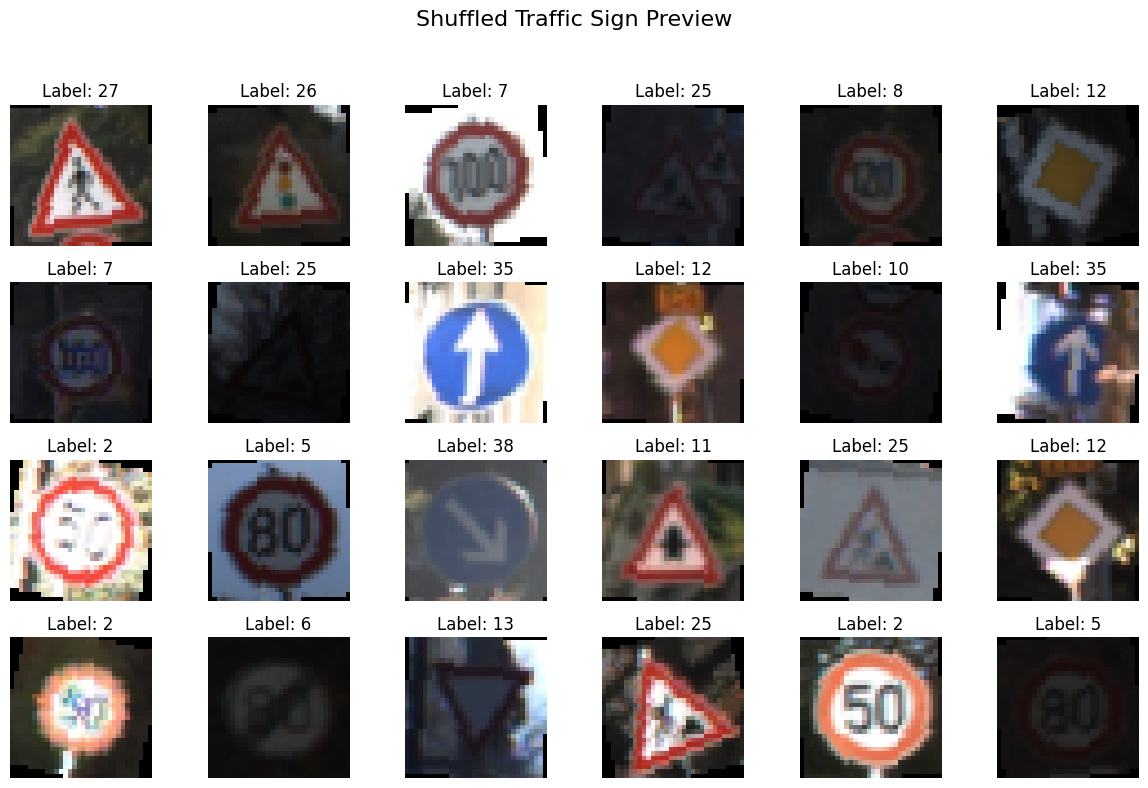

In [16]:
data_loader = DataLoader(dataset, batch_size=24, shuffle=True)
images, labels = next(iter(data_loader))
fig, axes = plt.subplots(4, 6, figsize=(12, 8))
fig.suptitle("Shuffled Traffic Sign Preview", fontsize=16)

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images):
        img = images[i].numpy().transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"Label: {labels[i]}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [13]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import Subset
from collections import defaultdict

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.RandomRotation(15), # Add random rotation of 15 degrees to mimic real world circumstance
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

targets = train_dataset.targets
class_indices = defaultdict(list)

for idx, label in enumerate(targets):
    class_indices[label].append(idx)

n_per_class = 500
selected_indices = []

for c in range(10):
    idxs = torch.tensor(class_indices[c])
    perm = idxs[torch.randperm(len(idxs))[:n_per_class]]
    selected_indices.extend(perm.tolist())

subset_dataset = Subset(train_dataset, selected_indices)

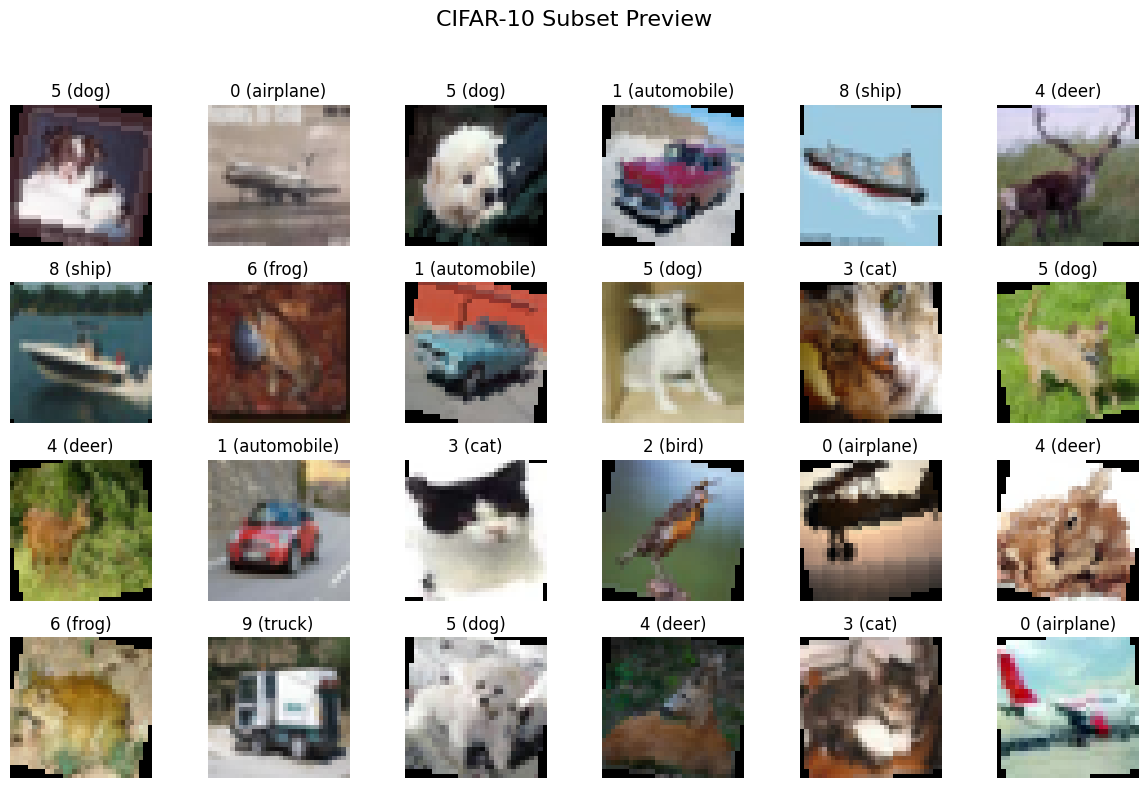

In [15]:
subset_dataset = Subset(train_dataset, selected_indices)

data_loader = DataLoader(subset_dataset, batch_size=24, shuffle=True)
images, labels = next(iter(data_loader))

class_names = train_dataset.classes

fig, axes = plt.subplots(4, 6, figsize=(12, 8))
fig.suptitle("CIFAR-10 Subset Preview", fontsize=16)

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(images):
        img = images[i].numpy().transpose(1, 2, 0)
        ax.imshow(img)
        ax.set_title(f"{labels[i].item()} ({class_names[labels[i].item()]})")
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()